# 注意力其实很稀疏：块稀疏入门

FlashAttention 把 full 注意力做到了又快又省显存，但它的计算量仍是 $O(S^2)$——每个 query 都要
和每个 key 算一遍。可你若真去看一眼注意力矩阵会发现：**大部分权重都集中在少数几段上下文**，
其余几乎是零。那为什么还要全算？

这一章我们走进**稀疏注意力**：把 key 切成块，每个 query 块只挑**最相关的 top-k 个 key 块**来算。
这是 DeepSeek NSA 等方法的核心地基。我们先用纯 PyTorch 把"选块 + 稀疏算"的机制讲透，
下一章再去读真正的稀疏 Triton kernel。


In [1]:
import sys, math
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "07-block-sparse-attention"))

from common import make_qkv, naive_attention, bench_ms
from block_sparse import select_topk_blocks, block_sparse_reference, block_sparse_attention, _pool_blocks

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))


跑在 NVIDIA GeForce RTX 4090


## 先亲眼看看：注意力到底有多稀疏

我们算一个真实的因果注意力矩阵，把它画出来，再统计每个 query "真正在意"的 key 有多少。


/tmp/ipykernel_2040194/3211458680.py:10: UserWarning: Glyph 22240 (\N{CJK UNIFIED IDEOGRAPH-56E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3211458680.py:10: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3211458680.py:10: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3211458680.py:10: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3211458680.py:10: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3211458680.py:10: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

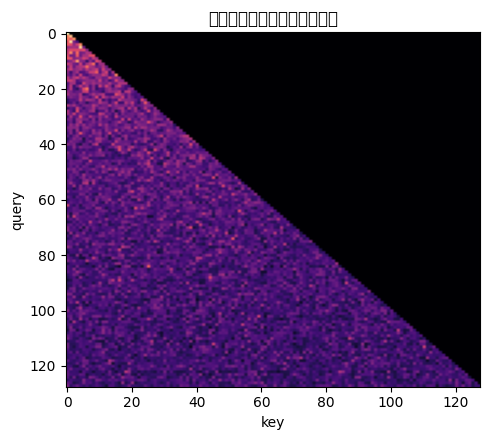

平均每个 query 要累计 90% 注意力，只需 40 个 key（共最多 128 个可见）——其余几乎是零。


In [2]:
q, k, v = make_qkv(1, 1, 128, 64, dtype=torch.float16, seed=0)
scores = (q.float() @ k.float().transpose(-1, -2)) / math.sqrt(64)
S = q.shape[2]
scores = scores.masked_fill(~torch.ones(S, S, device=q.device).tril().bool(), float("-inf"))
attn = torch.softmax(scores, dim=-1)[0, 0]      # (S,S)

plt.figure(figsize=(5, 4.5))
plt.imshow(attn.cpu().float().pow(0.3), cmap="magma", aspect="auto")  # ^0.3 提亮，便于看清
plt.title("因果注意力权重（越亮越大）"); plt.xlabel("key"); plt.ylabel("query")
plt.tight_layout(); plt.show()

# 每个 query：要累计到 90% 权重，平均需要多少个 key？
sorted_w = attn.sort(dim=-1, descending=True).values
cum = sorted_w.cumsum(-1)
need = (cum < 0.9).sum(-1).float() + 1          # 达到 90% 权重所需的 key 数
valid = torch.arange(1, S + 1, device=q.device).float()  # 每个 query 的可见 key 数(causal)
print(f"平均每个 query 要累计 90% 注意力，只需 {need.mean():.0f} 个 key（共最多 {S} 个可见）——其余几乎是零。")


## 三步：分块 → 选块 → 稀疏算

既然注意力这么稀疏，那就别全算。做三件事：

1. **分块 + pooled 代表**：把 query/key 按块取均值，每块得到一个"代表向量"；
2. **块级重要性 + top-k 选块**：用代表向量两两打分，每个 query 块选最相关的 top-k 个 key 块；
3. **稀疏计算**：只对选中的块算注意力。

第②步是灵魂。我们把"块级重要性矩阵"和"最终选中的块"并排画出来看：


/tmp/ipykernel_2040194/3741769232.py:17: UserWarning: Glyph 22359 (\N{CJK UNIFIED IDEOGRAPH-5757}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3741769232.py:17: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3741769232.py:17: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3741769232.py:17: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3741769232.py:17: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/3741769232.py:17: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

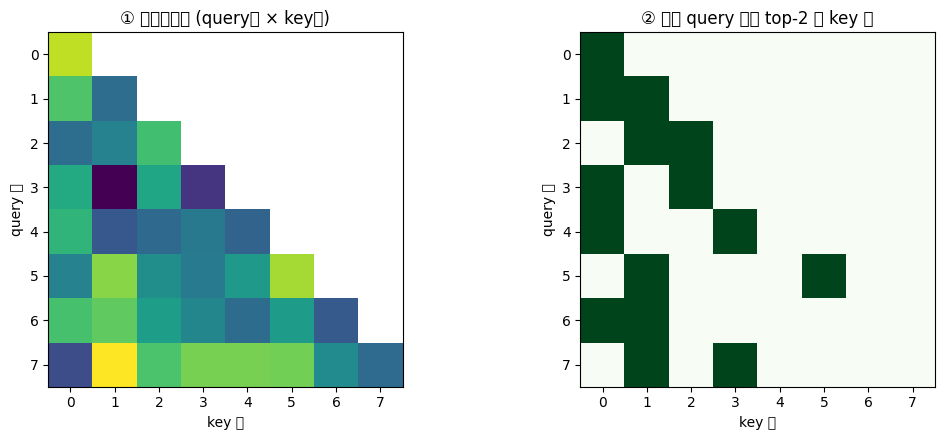

右图每行只有 2 个绿格——8 个 key 块里只算这 2 个，其余跳过。


In [3]:
q, k, v = make_qkv(1, 1, 256, 64, dtype=torch.float16, seed=1)
block_size, top_k = 32, 2
nb = 256 // block_size

q_blk, k_blk = _pool_blocks(q, block_size), _pool_blocks(k, block_size)
imp = (q_blk.float() @ k_blk.float().transpose(-1, -2) / math.sqrt(64))[0, 0]   # (nb,nb)
causal = torch.ones(nb, nb, device=q.device).tril().bool()
imp_vis = imp.masked_fill(~causal, float("nan"))

idx = select_topk_blocks(q, k, block_size, top_k, causal=True)[0, 0]            # (nb, top_k)
sel = torch.zeros(nb, nb, dtype=torch.bool, device=q.device)
sel.scatter_(1, idx, True); sel &= causal

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.imshow(imp_vis.cpu().float(), cmap="viridis"); ax1.set(title="① 块级重要性 (query块 × key块)", xlabel="key 块", ylabel="query 块")
ax2.imshow(sel.cpu().float(), cmap="Greens"); ax2.set(title=f"② 每个 query 块选 top-{top_k} 个 key 块", xlabel="key 块", ylabel="query 块")
plt.tight_layout(); plt.show()
print(f"右图每行只有 {top_k} 个绿格——{nb} 个 key 块里只算这 {top_k} 个，其余跳过。")


## 看看稀疏算子的代码

`block_sparse.py` 把这三步实现成两条路径：`block_sparse_reference`（mask + full，作 ground truth）
和 `block_sparse_attention`（gather 选中块、只算选中块）。直接读一下后者——稀疏计算就发生在这里：


In [4]:
from IPython.display import Code
Code(filename=str(ROOT / "07-block-sparse-attention" / "block_sparse.py"), language="python")


"""07 块稀疏注意力（入门）—— 稀疏注意力的地基。

标准注意力让每个 query 看**所有** key，计算量 O(S²)。块稀疏的想法是：把 key 切成块，
为每个 query 块只挑出**最相关的 top-k 个 key 块**来算，其余块直接不看。这正是 NSA 等方法
"selected（选择）"分支的核心。

关键三步：
  1. **分块 + pooled 代表**：把 query/key 按块取均值，得到每块的"代表向量"；
  2. **块级重要性 + top-k 选块**：用代表向量两两打分，每个 query 块选出最相关的 top-k 个 key 块；
  3. **稀疏计算**：只对选中的块算注意力。

本文件给两条等价路径：
  - `block_sparse_reference`：块稀疏 mask + full 注意力（ground truth，清楚地"看见"哪些块被选）；
  - `block_sparse_attention`：gather 出选中的块、**只对它们**算注意力（真正省计算）。
两者数值一致（`test_block_sparse.py` 验证）。真正高性能的稀疏 kernel（如 NSA 的 Triton 实现）
是下一章 08 的主题。
"""
from __future__ import annotations

import math

import torch


def _pool_blocks(x: torch.Tensor, block_size: int) -> torch.Tensor:
    """(B,H,S,D) 按 block_size 分块、每块取均值 → (B,H,nb,D) 的块代表。"""
    B, H, S, D = x.shape
    nb = S // block_size
    return x.view(B, H, nb, block_size, D).mean(dim=3)


def select_topk_blocks(q, k, block_size, top_k, *, causal=True):
    """为每个 query 块选出 top-k 个最相关的 key 块。

    返回 topk_idx: (B, H, nb, k_eff)，每个 query 块选中的 key 块索引（k_eff=min(top_k, 可选块数)）。
    """
    B, H, S, D = q.shape
    nb = S // block_size
    q_blk = _pool_blocks(q, block_size)                       # (B,H,nb,D)
    k_blk = _pool_blocks(k, block_size)
    imp = torch.matmul(q_blk.float(), k_blk.float().transpose(-1, -2)) / math.sqrt(D)  # (B,H,nb,nb)
    if causal:
        tri = torch.ones(nb, nb, device=q.device, dtype=torch.bool).tril()
        imp = imp.masked_fill(~tri, float("-inf"))            # query 块只能选 <= 自己的 key 块
    k_eff = min(top_k, nb)
    return imp.topk(k_eff, dim=-1).indices                    # (B,H,nb,k_eff)


def _block_mask_from_idx(topk_idx, nb):
    """topk_idx (B,H,nb,k) → block_mask (B,H,nb,nb) bool（块 i 是否选了块 j）。"""
    B, H, nbq, _ = topk_idx.shape
    bm = torch.zeros(B, H, nbq, nb, device=topk_idx.device, dtype=torch.bool)
    return bm.scatter(-1, topk_idx, True)


def block_sparse_reference(q, k, v, block_size, top_k, *, causal=True, sm_scale=None):
    """ground truth：把块选择展开成 token 级 mask，再做一次普通（full）注意力。

    不省计算，但最直观——能清楚看到"哪些块被选中、哪些被屏蔽"。
    """
    B, H, S, D = q.shape
    nb = S // block_size
    if sm_scale is None:
        sm_scale = 1.0 / math.sqrt(D)

    topk_idx = select_topk_blocks(q, k, block_size, top_k, causal=causal)
    block_mask = _block_mask_from_idx(topk_idx, nb)           # (B,H,nb,nb)
    # 块级 mask 展开到 token 级
    token_mask = block_mask.repeat_interleave(block_size, 2).repeat_interleave(block_size, 3)
    if causal:
        token_mask &= torch.ones(S, S, device=q.device, dtype=torch.bool).tril()

    scores = torch.matmul(q.float(), k.float().transpose(-1, -2)) * sm_scale
    scores = scores.masked_fill(~token_mask, float("-inf"))
    attn = torch.softmax(scores, dim=-1)
    return torch.matmul(attn, v.float()).to(q.dtype)


def block_sparse_attention(q, k, v, block_size, top_k, *, causal=True, sm_scale=None):
    """省计算的实现：gather 出每个 query 块选中的 key 块，**只对它们**算注意力。

    计算量从 O(nb·nb) 个块降到 O(nb·top_k) 个块。全程向量化（无 Python 循环）。
    """
    B, H, S, D = q.shape
    nb = S // block_size
    if sm_scale is None:
        sm_scale = 1.0 / math.sqrt(D)
    topk_idx = select_topk_blocks(q, k, block_size, top_k, causal=causal)  # (B,H,nb,kk)
    kk = topk_idx.shape[-1]

    k_blocks = k.view(B, H, nb, block_size, D)
    v_blocks = v.view(B, H, nb, block_size, D)
    # gather 每个 query 块选中的 key/value 块 → (B,H,nb,kk,block_size,D)
    idx = topk_idx[..., None, None].expand(B, H, nb, kk, block_size, D)
    k_sel = torch.gather(k_blocks[:, :, None].expand(B, H, nb, nb, block_size, D), 3, idx)
    v_sel = torch.gather(v_blocks[:, :, None].expand(B, H, nb, nb, block_size, D), 3, idx)
    k_sel = k_sel.reshape(B, H, nb, kk * block_size, D)
    v_sel = v_sel.reshape(B, H, nb, kk * block_size, D)

    q_blk = q.view(B, H, nb, block_size, D)
    # 每个 query 块只和自己选中的 kk 个块算注意力
    scores = torch.einsum("bhnqd,bhnkd->bhnqk", q_blk.float(), k_sel.float()) * sm_scale

    if causal:
        # 选中块在序列里的全局位置由 topk_idx 决定，据此构造 causal 掩码
        q_pos =

## 验证：两条路径一致，全选时退化为 full

- gather 省算实现，必须和 mask 参考实现数值一致；
- 当 top-k 取满（选中所有块）时，块稀疏必须退化成普通 full 注意力。


In [5]:
q, k, v = make_qkv(2, 4, 512, 64, dtype=torch.float16, seed=2)
nb = 512 // 64

# gather ≡ reference
for tk in [1, 2, 4]:
    ref = block_sparse_reference(q, k, v, 64, tk, causal=True)
    gat = block_sparse_attention(q, k, v, 64, tk, causal=True)
    print(f"top_k={tk}: gather vs mask参考 最大差异 {(ref-gat).abs().max().item():.1e}  ✓")

# 全选 ≡ full
full = naive_attention(q, k, v, causal=True)
allsel = block_sparse_reference(q, k, v, 64, top_k=nb, causal=True)
print(f"\ntop_k={nb}(全选) vs full 注意力 最大差异 {(full-allsel).abs().max().item():.1e}  ✓ 退化为 full")


top_k=1: gather vs mask参考 最大差异 0.0e+00  ✓
top_k=2: gather vs mask参考 最大差异 2.4e-04  ✓
top_k=4: gather vs mask参考 最大差异 2.4e-04  ✓

top_k=8(全选) vs full 注意力 最大差异 0.0e+00  ✓ 退化为 full


## 省了多少？以及为什么还需要稀疏 kernel

块稀疏只算选中块，所以 top-k 越小越快。但我们的 gather 是**纯 PyTorch**（gather/scatter 有开销），
和融合的 SDPA 比并不占便宜。看数据：


/tmp/ipykernel_2040194/1834861108.py:15: UserWarning: Glyph 31232 (\N{CJK UNIFIED IDEOGRAPH-7A00}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/1834861108.py:15: UserWarning: Glyph 30095 (\N{CJK UNIFIED IDEOGRAPH-758F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/1834861108.py:15: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/1834861108.py:15: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/1834861108.py:15: UserWarning: Glyph 36873 (\N{CJK UNIFIED IDEOGRAPH-9009}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2040194/1834861108.py:15: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp

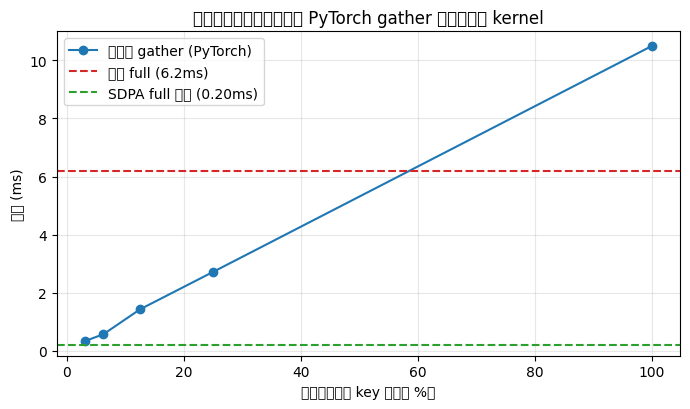

选 2/32 块(6%): 0.58ms，比朴素 full 快 11×，但仍慢于 SDPA 的 0.20ms。


In [6]:
S, block_size, nb = 2048, 64, 32
q, k, v = make_qkv(4, 8, S, 64, dtype=torch.float16, seed=0)
ms_naive = bench_ms(lambda: naive_attention(q, k, v, causal=True))
ms_sdpa = bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True))

tks = [1, 2, 4, 8, nb]
lat = [bench_ms(lambda tk=tk: block_sparse_attention(q, k, v, block_size, tk, causal=True)) for tk in tks]

plt.figure(figsize=(7, 4.2))
plt.plot([t/nb*100 for t in tks], lat, "o-", label="块稀疏 gather (PyTorch)")
plt.axhline(ms_naive, ls="--", c="C3", label=f"朴素 full ({ms_naive:.1f}ms)")
plt.axhline(ms_sdpa, ls="--", c="C2", label=f"SDPA full 融合 ({ms_sdpa:.2f}ms)")
plt.xlabel("稀疏度（选中 key 块占比 %）"); plt.ylabel("延迟 (ms)"); plt.legend(); plt.grid(alpha=0.3)
plt.title("块稀疏：少算块就快，但 PyTorch gather 干不过融合 kernel")
plt.tight_layout(); plt.show()
print(f"选 2/{nb} 块(6%): {lat[1]:.2f}ms，比朴素 full 快 {ms_naive/lat[1]:.0f}×，但仍慢于 SDPA 的 {ms_sdpa:.2f}ms。")


## 深度优化版：复用 08 NSA 的真实 triton kernel

上面说"要既稀疏又快，必须把选块 + 稀疏算焊进一个 Triton kernel"。这样的 kernel 长什么样？其实 07 的
"动态 top-k 块稀疏"**正是 08 NSA 的 selected 分支** —— 开源生态里没有独立、干净、4090 可跑的"动态块
稀疏 triton kernel"（NSA 那种与压缩/滑窗耦合、MoBA 用 flash_attn、triton 旧 blocksparse 已移除），
所以本章深度优化版直接**复用 08 已提取并验证的** `native_sparse_attend`。

**语义升级：对角块必看 + top-k 历史块。** 真实 kernel 比简要版的"纯 top-k"多一条规矩：当前块（对角块）
**总是**算（NSA 用 Part1 处理对角块、selected 只选互补的历史块）。这是动态块稀疏的通用工程选择。

In [7]:
from block_sparse_triton import block_sparse_attention_triton, block_sparse_nsa_reference

qd, kd, vd = make_qkv(2, 4, 512, 64, dtype=torch.float16, seed=3)
bs2, nb2 = 64, 512 // 64

# 锚点：选满所有历史块 → 退化为 full causal
o_full = block_sparse_attention_triton(qd, kd, vd, bs2, top_k=nb2)
full = naive_attention(qd, kd, vd, causal=True)
print(f"全历史选块 vs full causal   max diff = {(o_full - full).abs().max().item():.5f}")

# 各 top-k：复用的 NSA kernel vs 匹配语义的 PyTorch 参考（对角块 + top-k 历史块）
for tk in [1, 2, 4]:
    o = block_sparse_attention_triton(qd, kd, vd, bs2, tk)
    r = block_sparse_nsa_reference(qd, kd, vd, bs2, tk)
    print(f"top_k={tk}: 复用 NSA kernel vs 参考   max diff = {(o - r).abs().max().item():.4f}")
print("→ 复用 08 NSA selected kernel：语义=对角块必看+top-k历史，全历史时退化为 full causal。")

全历史选块 vs full causal   max diff = 0.00195
top_k=1: 复用 NSA kernel vs 参考   max diff = 0.0020
top_k=2: 复用 NSA kernel vs 参考   max diff = 0.0020
top_k=4: 复用 NSA kernel vs 参考   max diff = 0.0020
→ 复用 08 NSA selected kernel：语义=对角块必看+top-k历史，全历史时退化为 full causal。


## 对照：MoBA —— 另一条动态块稀疏路线

Kimi 的 **MoBA**（Mixture of Block Attention）是与 NSA 同期的动态块稀疏。纯 PyTorch 参考
`moba_naive.py` 可直接跑：chunk 级动态 top-k 选块 + **当前块强制选中**（和本章"对角块必看"一个道理）。

In [8]:
from moba_naive import moba_attn_varlen_naive

S2 = 256
qm = torch.randn(S2, 2, 64, device="cuda", dtype=torch.float16)
km = torch.randn(S2, 2, 64, device="cuda", dtype=torch.float16)
vm = torch.randn(S2, 2, 64, device="cuda", dtype=torch.float16)
cu = torch.tensor([0, S2], device="cuda", dtype=torch.int32)

o_moba = moba_attn_varlen_naive(qm, km, vm, cu, S2, moba_chunk_size=64, moba_topk=2)
print("MoBA naive 输出:", tuple(o_moba.shape))

# 选满所有 chunk → full causal
o_all = moba_attn_varlen_naive(qm, km, vm, cu, S2, moba_chunk_size=64, moba_topk=S2 // 64)
fm = naive_attention(qm.transpose(0, 1)[None], km.transpose(0, 1)[None],
                     vm.transpose(0, 1)[None], causal=True)[0].transpose(0, 1)
print(f"MoBA 全选 vs full causal     max diff = {(o_all - fm).abs().max().item():.5f}")
print("→ MoBA：chunk 级动态选块 + 当前块必选；高效版用 flash_attn varlen 编排（见 moba_efficient.py）。")

MoBA naive 输出: (256, 2, 64)
MoBA 全选 vs full causal     max diff = 0.00000
→ MoBA：chunk 级动态选块 + 当前块必选；高效版用 flash_attn varlen 编排（见 moba_efficient.py）。


In [9]:
from IPython.display import Code
# MoBA 的纯 PyTorch 参考（可跑）；高效版 moba_efficient.py 依赖 flash_attn，仅供阅读
Code(filename=str(ROOT / "07-block-sparse-attention" / "moba_naive.py"), language="python")

# =============================================================================
# 来源标注 (Provenance) —— 本仓库 07-block-sparse-attention 的 MoBA 对照（补充）
# -----------------------------------------------------------------------------
# 完整拷贝自 Kimi / Moonshot AI 的 MoBA（Mixture of Block Attention），**计算逻辑一字未改**。
# MoBA 是另一种"动态 top-k 块稀疏"，与 07 简要版同源、与 08 NSA selected 思路一致。
#   source repo : https://github.com/MoonshotAI/MoBA
#   source file : moba/moba_naive.py
#   commit      : b5d58363311d3ca946f1ec444182727c15e338b5
#   license     : MIT (Copyright © 2025 Moonshot AI)
#
# 这是 MoBA 的**纯 PyTorch 参考实现**（无外部依赖，可直接跑）：把 KV 按 chunk 分块、用块
# 均值算 gate、每个 query 选 top-k 个 chunk；**当前块强制选中**（见下方 gate[i块,i块]=inf）
# —— 与本仓库"对角块必看"（block_sparse_triton.py）异曲同工。高效版见 moba_efficient.py。
# 详见同目录 SOURCES.md / README.md 与仓库根 NOTICE。
# =============================================================================
"""A clean version of moba implementation for educational purposes"""

import torch
import math


def moba_attn_varlen_naive(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    cu_seqlens: torch.Tensor,
    max_seqlen: int,
    moba_chunk_size: int,
    moba_topk: int,
) -> torch.Tensor:
    """Implement the moba brute-force setting for reference

    Args:
        q (torch.Tensor): [seqlen, head, head_dim]
        k (torch.Tensor): [seqlen, head, head_dim]
        v (torch.Tensor): [seqlen, head, head_dim]
        cu_seqlens (torch.Tensor): the cumulative sequence length tensor, same definition in flash attn
        max_seqlen (int): the max sequence length of the batch, same definition in flash attn

    Returns:
        attn_output (torch.Tensor): [seqlen, head, head_dim]
    """

    # qkv shape = [ S, H, D ]
    batch = cu_seqlens.numel() - 1
    softmax_scale = q.shape[-1] ** (-0.5)

    o = torch.zeros_like(q)
    for batch_idx in range(batch):
        batch_start = cu_seqlens[batch_idx].item()
        batch_end = cu_seqlens[batch_idx + 1].item()
        # get qkv of this batch
        q_ = q[batch_start:batch_end]
        k_ = k[batch_start:batch_end]
        v_ = v[batch_start:batch_end]
        o_ = o[batch_start:batch_end]
        # calc key gate weight
        key_gate_weight = []
        batch_size = batch_end - batch_start
        num_block = math.ceil(batch_size / moba_chunk_size)
        for block_idx in range(0, num_block):
            block_start = block_idx * moba_chunk_size
            block_end = min(batch_size, block_start + moba_chunk_size)
            key_gate_weight.append(k_[block_start:block_end].mean(dim=0, keepdim=True))
        key_gate_weight = torch.cat(key_gate_weight, dim=0)  # [ N, H, D ]
        # calc & mask gate
        # use fp32 to avoid precision issue in bf16
        q_ = q_.type(torch.float32)
        key_gate_weight = key_gate_weight.type(torch.float32)
        gate = torch.einsum("shd,nhd->hsn", q_, key_gate_weight)  # [ H, S, N ]
        key_gate_weight = key_gate_weight.type_as(k)
        q_ = q_.type_as(k)
        for i in range(num_block):
            # select the future Qs that can attend to KV chunk i
            gate[:, : (i + 1) * moba_chunk_size, i] = float("-inf")
            gate[:, i * moba_chunk_size : (i + 1) * moba_chunk_size, i] = float("inf")
        # gate_top_k_idx = gate_top_k_val = [ H S K ]
        gate_top_k_val, gate_top_k_idx = torch.topk(
            gate, k=min(moba_topk, num_block), dim=-1, largest=True, sorted=False
        )
        gate_top_k_val, _ = gate_top_k_val.min(dim=-1)  # [ H, S ]
        need_attend = gate >= gate_top_k_val.unsqueeze(-1)
        # add gate_idx_mask in case of there is cornercases of same topk val been selected
        gate_idx_mask = torch.zeros(
            need_attend.shape, dtype=torch.bool, device=q.device
        )
        gate_idx_mask = gate_idx_mask.scatter_(dim=-1, index=gate_top_k_idx, value=True)
        need_attend = torch.logical_and(need_attend, gate_idx_mask)
        gate[need_attend] = 0
        gate[~need_attend] = -flo

### 两条落地路线对照

| | 08 NSA（07 深度优化版复用） | MoBA |
|---|---|---|
| 高效实现 | **自写**稀疏 triton kernel（选块 gather 融进 flash） | **借** flash_attn varlen + 数据重排 |
| 当前块 | 对角块必看（kernel Part1） | 当前块必选（gate=inf） |
| 依赖 | triton / einx（本仓库已跑通 fwd+bwd） | flash-attn（本环境未装；naive 版可跑） |

都"动态选块"，但工程路线不同：自写 kernel（NSA）极致但难写；借 flash_attn（MoBA）省力但受限于 flash 的接口。

## 收尾

- 注意力天然**稀疏**：每个 query 的权重集中在少数块上；
- 块稀疏三步——分块取代表 → 块级 top-k 选块 → 只算选中块；
- **简要版**（`block_sparse.py`）用纯 PyTorch 讲清机制（纯 top-k）；**深度优化版**
  （`block_sparse_triton.py`）复用 08 NSA 的真实 triton kernel（语义=对角块必看+top-k历史），
  证明"既稀疏又快"要靠融合 kernel；
- **MoBA 对照**（`moba_naive.py` / `moba_efficient.py`）展示了动态块稀疏的另一条落地路线。

**下一站** → `08-native-sparse-attention`：把"压缩 + 选择 + 滑窗"三分支门控合并，逐段精读那 1987 行
真实稀疏 Triton kernel。